# Stationary states in time: why one stands still and two dance
### the time-independent Schrodinger equation, set in motion

Solving $H\psi_n=E_n\psi_n$ (the time-independent Schrodinger equation) gives the **stationary
states**. Each evolves by only a phase,
$$\Psi_n(x,t)=\psi_n(x)\,e^{-iE_nt/\hbar},$$
so its probability density $|\Psi_n|^2$ never changes -- it *stands still*. But a **superposition**
$$\Psi(x,t)=\sum_n c_n\,\psi_n(x)\,e^{-iE_nt/\hbar}$$
moves: two levels beat at the **Bohr frequency** $\omega=(E_2-E_1)/\hbar$, and $\langle x\rangle$
sloshes back and forth -- the quantum origin of a spectral line. This notebook, using the
infinite-well eigenstates from `dgs/stationary_states.py`, shows a single state holding still
while its phase spins, then two states dancing. Civilian education.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import stationary_states as ss
L = 1.0
x = np.linspace(0, L, 1000)
psi1 = ss.infinite_well_eigenstate(1, x, L); E1 = ss.infinite_well_energy(1)
psi2 = ss.infinite_well_eigenstate(2, x, L); E2 = ss.infinite_well_energy(2)
print("E1=%.3f, E2=%.3f, Bohr omega_21=%.3f" % (E1, E2, ss.bohr_frequency(E2,E1)))

E1=4.935, E2=19.739, Bohr omega_21=14.804


## 1. A single stationary state: $|\Psi|^2$ frozen, phase spinning

$\Psi_1=\psi_1e^{-iE_1t}$: the complex amplitude rotates in the plane ($\mathrm{Re}$ shrinks and
grows), but the density $|\Psi_1|^2=|\psi_1|^2$ is dead flat in time. This is exactly why an atom
in an energy eigenstate does not radiate -- nothing observable oscillates.

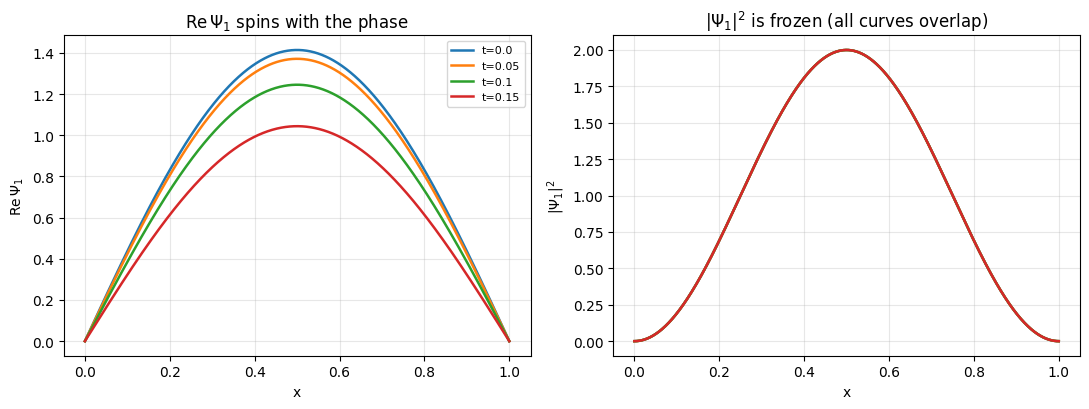

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for t in (0.0, 0.05, 0.10, 0.15):
    Psi = ss.evolve([1.0], [psi1], [E1], t)
    ax[0].plot(x, Psi.real, lw=1.8, label=f"t={t}")
ax[0].set(xlabel="x", ylabel="Re$\\,\\Psi_1$", title="Re$\\,\\Psi_1$ spins with the phase")
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
for t in (0.0, 0.05, 0.10, 0.15):
    ax[1].plot(x, ss.probability_density(ss.evolve([1.0],[psi1],[E1],t)), lw=1.8)
ax[1].set(xlabel="x", ylabel="$|\\Psi_1|^2$", title="$|\\Psi_1|^2$ is frozen (all curves overlap)")
ax[1].grid(alpha=0.3); plt.tight_layout(); plt.show()

## 2. Two states superposed: the density sloshes

Mix $n=1$ and $n=2$ equally. The cross term $\propto\cos(\omega_{21}t)$ makes $|\Psi|^2$ pile up
on the left, then the right, then back -- a wave rocking side to side with period
$T=2\pi/\omega_{21}$. Four snapshots over one period:

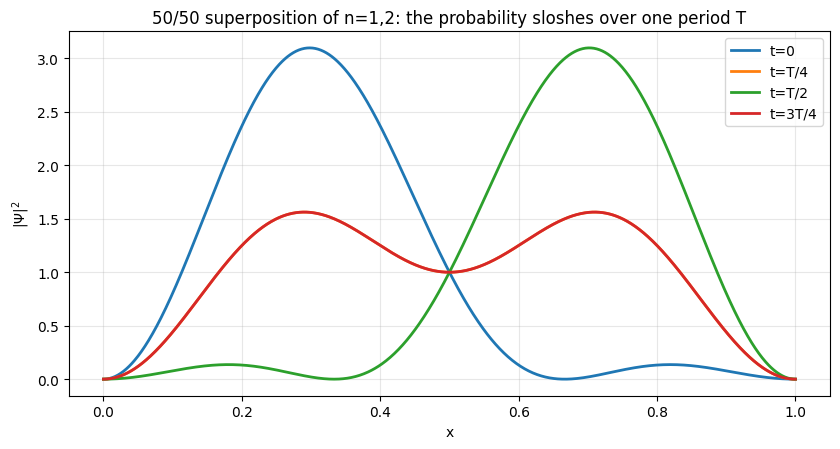

In [3]:
c = [1/np.sqrt(2), 1/np.sqrt(2)]
w = ss.bohr_frequency(E2, E1); T = 2*np.pi/w
plt.figure(figsize=(8.5, 4.6))
for frac, tag in [(0.0,"t=0"), (0.25,"t=T/4"), (0.5,"t=T/2"), (0.75,"t=3T/4")]:
    P = ss.probability_density(ss.evolve(c, [psi1, psi2], [E1, E2], frac*T))
    plt.plot(x, P, lw=2, label=tag)
plt.xlabel("x"); plt.ylabel("$|\\Psi|^2$")
plt.title("50/50 superposition of n=1,2: the probability sloshes over one period T")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 3. $\langle x\rangle(t)$ oscillates at the Bohr frequency

Track the mean position through time. It is a clean sinusoid at $\omega_{21}=(E_2-E_1)/\hbar$,
swinging about the center $x=L/2$. A charged particle doing this **radiates** at that frequency --
the emitted photon carries energy $\hbar\omega_{21}=E_2-E_1$, which is why atomic transitions make
sharp spectral lines.

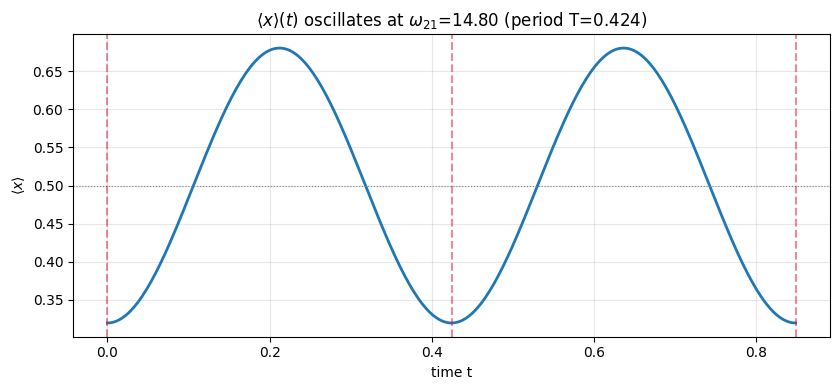

FFT peak angular frequency = 14.755  vs  Bohr omega_21 = 14.804


In [4]:
ts = np.linspace(0, 2*T, 300)
xs = [ss.expectation_position(ss.evolve(c, [psi1, psi2], [E1, E2], t), x) for t in ts]
plt.figure(figsize=(8.5, 4))
plt.plot(ts, xs, lw=2)
plt.axhline(0.5, color="gray", lw=0.8, ls=":")
for k in range(3):
    plt.axvline(k*T, color="crimson", ls="--", alpha=0.5)
plt.xlabel("time t"); plt.ylabel("$\\langle x\\rangle$")
plt.title(f"$\\langle x\\rangle(t)$ oscillates at $\\omega_{{21}}$={w:.2f} (period T={T:.3f})")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
# frequency check via FFT
xd = np.array(xs) - np.mean(xs); dt = ts[1]-ts[0]
f = np.fft.rfftfreq(len(xd), dt); peak = f[np.argmax(np.abs(np.fft.rfft(xd)))]
print("FFT peak angular frequency = %.3f  vs  Bohr omega_21 = %.3f" % (2*np.pi*peak, w))

## 4. Every gap is a spectral line

The frequency at which a superposition of two levels oscillates -- hence the photon it emits --
is set purely by the ENERGY GAP. The infinite well's levels go as $n^2$, so the transition
frequencies (and line energies $\hbar\omega=E_m-E_n$) are fixed by the quantum numbers alone.

In [5]:
print("transition   Delta_E = E_m - E_n = hbar*omega  (the spectral line)")
for (a, b) in [(1,2),(1,3),(2,3),(2,4)]:
    Ea, Eb = ss.infinite_well_energy(a), ss.infinite_well_energy(b)
    print(f"  {a} -> {b}:  Delta_E = {Eb-Ea:7.3f}  (omega = {ss.bohr_frequency(Eb,Ea):7.3f})")

transition   Delta_E = E_m - E_n = hbar*omega  (the spectral line)
  1 -> 2:  Delta_E =  14.804  (omega =  14.804)
  1 -> 3:  Delta_E =  39.478  (omega =  39.478)
  2 -> 3:  Delta_E =  24.674  (omega =  24.674)
  2 -> 4:  Delta_E =  59.218  (omega =  59.218)


## What we saw

* A **stationary state** carries a spinning phase but a **frozen** $|\Psi|^2$ -- no observable
  changes, so an energy eigenstate does not radiate.
* A **superposition** evolves as each coefficient rotates at its own $e^{-iE_nt/\hbar}$; two levels
  **beat** at $\omega=(E_2-E_1)/\hbar$, and $\langle x\rangle$ oscillates at exactly that frequency
  (verified by FFT).
* That energy-gap frequency is the **spectral line** -- $\hbar\omega=E_m-E_n$.

Time evolution on top of the eigenvalue solvers `dgs/quantum_oscillator.py` and
`dgs/finite_square_well.py`: solve the time-independent equation for $\psi_n$, then let each
phase spin.